# Problem Set 6: Neural Networks


<span style="color:red">Warning!</span> Some of the problems in this problem set require heavy computation - you are encouraged to start early so that you don't get stuck at the last minute.

# Section 1: Neural Network Architecture

In the first section of this problem set, we'll spend some time examining neural network model architecture. Please type in your answers after each question -- this section requires no coding.

### Question 1.1

Consider an input image of dimensions 150 X 150 X 3: i.e., height and width of 150 pixels, with 3 channels.

1.1.1 Suppose you feed this image into a fully connected (dense) layer with 512 neurons. How many learnable / trainable parameters (or weights) does this layer have?
    
1.1.2 Now, suppose we feed this image into a Conv2D layer with 512 filters, kernel size 3 x 3, and stride 1 (assume 0 padding). How many learnable / trainable parameters (or weights) does this layer have?


#### Your Answer Here

1.1.1:
- For a fully connected dense layer with 512 neurons, each neuron will have 150x150x3 weights associated with it, since each neuron is connected to each pixel in the input image. Therefore the number of trainable parameters will be 150×150×3×512 = 32,400,000 weights

1.1.2:
- A Conv2D layer with kernel size 3x3, will have (3x3)x3 weights for each filter given 3 input channels. Given 512 filters and a bias term for each filter, this leaves us with:
((3x3)x3)x512 + 512 = 14,336


### Question 1.2

Consider the following CNN, and answer the related questions. Assume that your input images are of dimensions (150, 150, 3): i.e., height and width of 150 pixels, with 3 channels.

**1.2.1**: Complete the table -- fill in the missing entries (A, B, C, D). For each missing entry, provide a brief explanation for your answer (No more than 2 brief sentences.)

- Hint: The Keras documentation [MaxPooling2D](https://keras.io/api/layers/pooling_layers/max_pooling2d/) will be of use

![Model image](https://github.com/neurogomez/INFO201_AppliedMachineLearning/blob/main/PS/PS6/images/model1-verbose.png?raw=1)

**1.2.2**: Report the total number of parameters in this model?

**1.2.3**: Consider Layer 2 from above. Suppose we change the stride to 2, how does it affect the output shape (A) that you calculated above? How does it affect the number of parameters (B)?

#### Your Answer Here

**1.2.1**:

A. To get the ouptput height / width we can use the following formulation: (input_height/width - filter_height/width + 2 x padding)/stride + 1
- Therefore in our case we would get an ouput shape: (146, 146, 64), where 64 refers to the number of filters.

B. Following similar logic to 1.1.2 for the number of parameters, but this time taking into account our input shape ( 148, 148, 32), we get:
- Num of params = (3x3)x32x64 + 64 = 18,496

C. Following the similar logic as A, the ouputput height/width would be (input_height - pool_height)/stride + 1
- Output shape = (73,73, 64)

D. Following similar logic to 1.1.2 for the number of parameters we get:
- Num of params = (3x3)x64x64 + 64 = 36928

**1.2.2**:
- Layer 1: Conv2D = 896
- Layer 2: Conv2D = 18496
- Layer 3: MaxPooling2D = 0
- Layer 4: Conv2D = 36928
- Layer 5: MaxPooling2D = 0
- _Total number of parameters_ = 896 + 18496 + 0 + 36928 + 0 = 56320

    
**1.2.3**:
- Changing Layer 2 to have stride 2 will change the output height and width. Using the formulation from 1.2.1, we would get (73, 73, 64). THe number of parameters would not be affected since this value depends on the kernel size, number of channels and number of filters.






# Section 2: Truck v/s Cars: Neural Networks and Image Classification

Your goal for this problem set is to train neural network models for image classification. Specifically, your task is to train models that correctly predict where the vehicle in a given image is a truck, or a car / automobile.

It might be useful to start by implementing this entire problem set on a relatively small subset of all of the images first, before using the full dataset.

## 2.1. Load Data +  Exploratory Analysis

For this problem, we'll load the [CIFAR 10](https://keras.io/api/datasets/cifar10/) dataset, from the Keras API. This dataset has been widely used in ML and computer vision research -- you can read more about the state of the art model performance (and how this has improved over time) [here](https://en.wikipedia.org/wiki/CIFAR-10).

The CIFAR 10 dataset originally has 10 classes -- we've provided helper code below to load the data, and remove images belonging to unnecessary classes. We will use this dataset for a supervised binary classification problem.

Your tasks:
 1. Extract a validation set from your training data. Keep 70% of the images for training, while the remainder will be used for validation.
 2. Examine a single image in from your training set. Report the dimensions (width, height, number of channels.) Plot each channel.
 3. Select 9 random images from your training set. Plot these images in a 3 X 3 grid, along with the corresponding category / label
 4. Plot the distribution of labels in your training, validation and test sets.


In [3]:
from keras.datasets import cifar10
import numpy as np
def cifar_2classes():
    """
    Helper code to clean the CIFAR 10 dataset, and remove the unnecessary classes.
    """
    ## Load data
    label_names = ["airplane",
             "automobile",
             "bird",
             "cat",
             "deer",
             "dog",
             "frog",
             "horse",
             "ship",
             "truck"]


    label_map = {0:99, 1:0, 2:99, 3:99, 4:99, 5:99, 6:99, 7:99, 8:99, 9:1}

    (X_train_val, y_train_val), (X_test, y_test) = cifar10.load_data()

    (X_train_val, y_train_val), (X_test, y_test) = cifar10.load_data()
    y_train_val1 = np.array([[label_map[y[0]]] for y in y_train_val])
    y_test1 = np.array([[label_map[y[0]]] for y in y_test])

    X_train_val_clean = X_train_val[np.where(y_train_val1 != 99)[0]]
    y_train_val_clean =  y_train_val1[np.where(y_train_val1 != 99)]

    X_test_clean = X_test[np.where(y_test1 != 99 )[0]]
    y_test_clean = y_test1[np.where(y_test1 != 99)]

    return X_train_val_clean, y_train_val_clean, X_test_clean, y_test_clean

In [4]:
## Load data
X_train_val, y_train_val, X_test, y_test = cifar_2classes()

170498071/170498071 [==============================] - 4s 0us/step


In [5]:
## 1. Split into train, validation and test.
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.3)

X_train.shape


(7000, 32, 32, 3)

2. The dimensions of an image are [w, h, ch] = (32, 32, 3) and there are 3 channels.

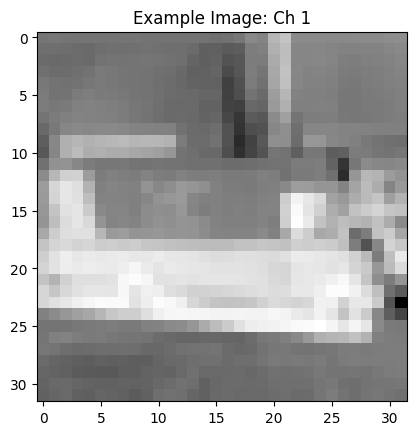

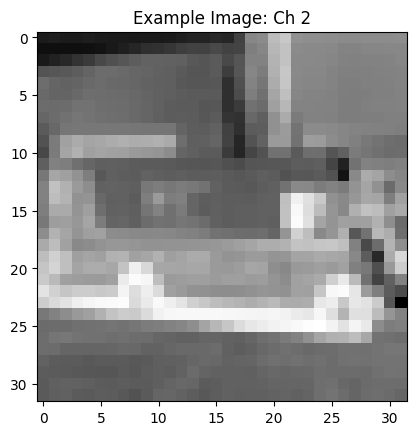

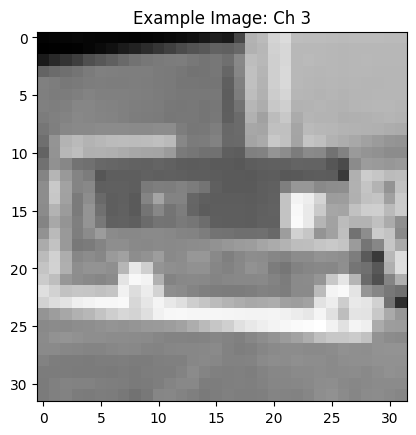

In [27]:
# 2. Plot example image sperated by channel
import matplotlib.pyplot as plt
for ch in range(X_train.shape[3]):
  plt.imshow(X_train[1,:,:,ch], cmap = 'Greys')
  plt.title('Example Image: Ch '+ str(ch+1))
  plt.show()

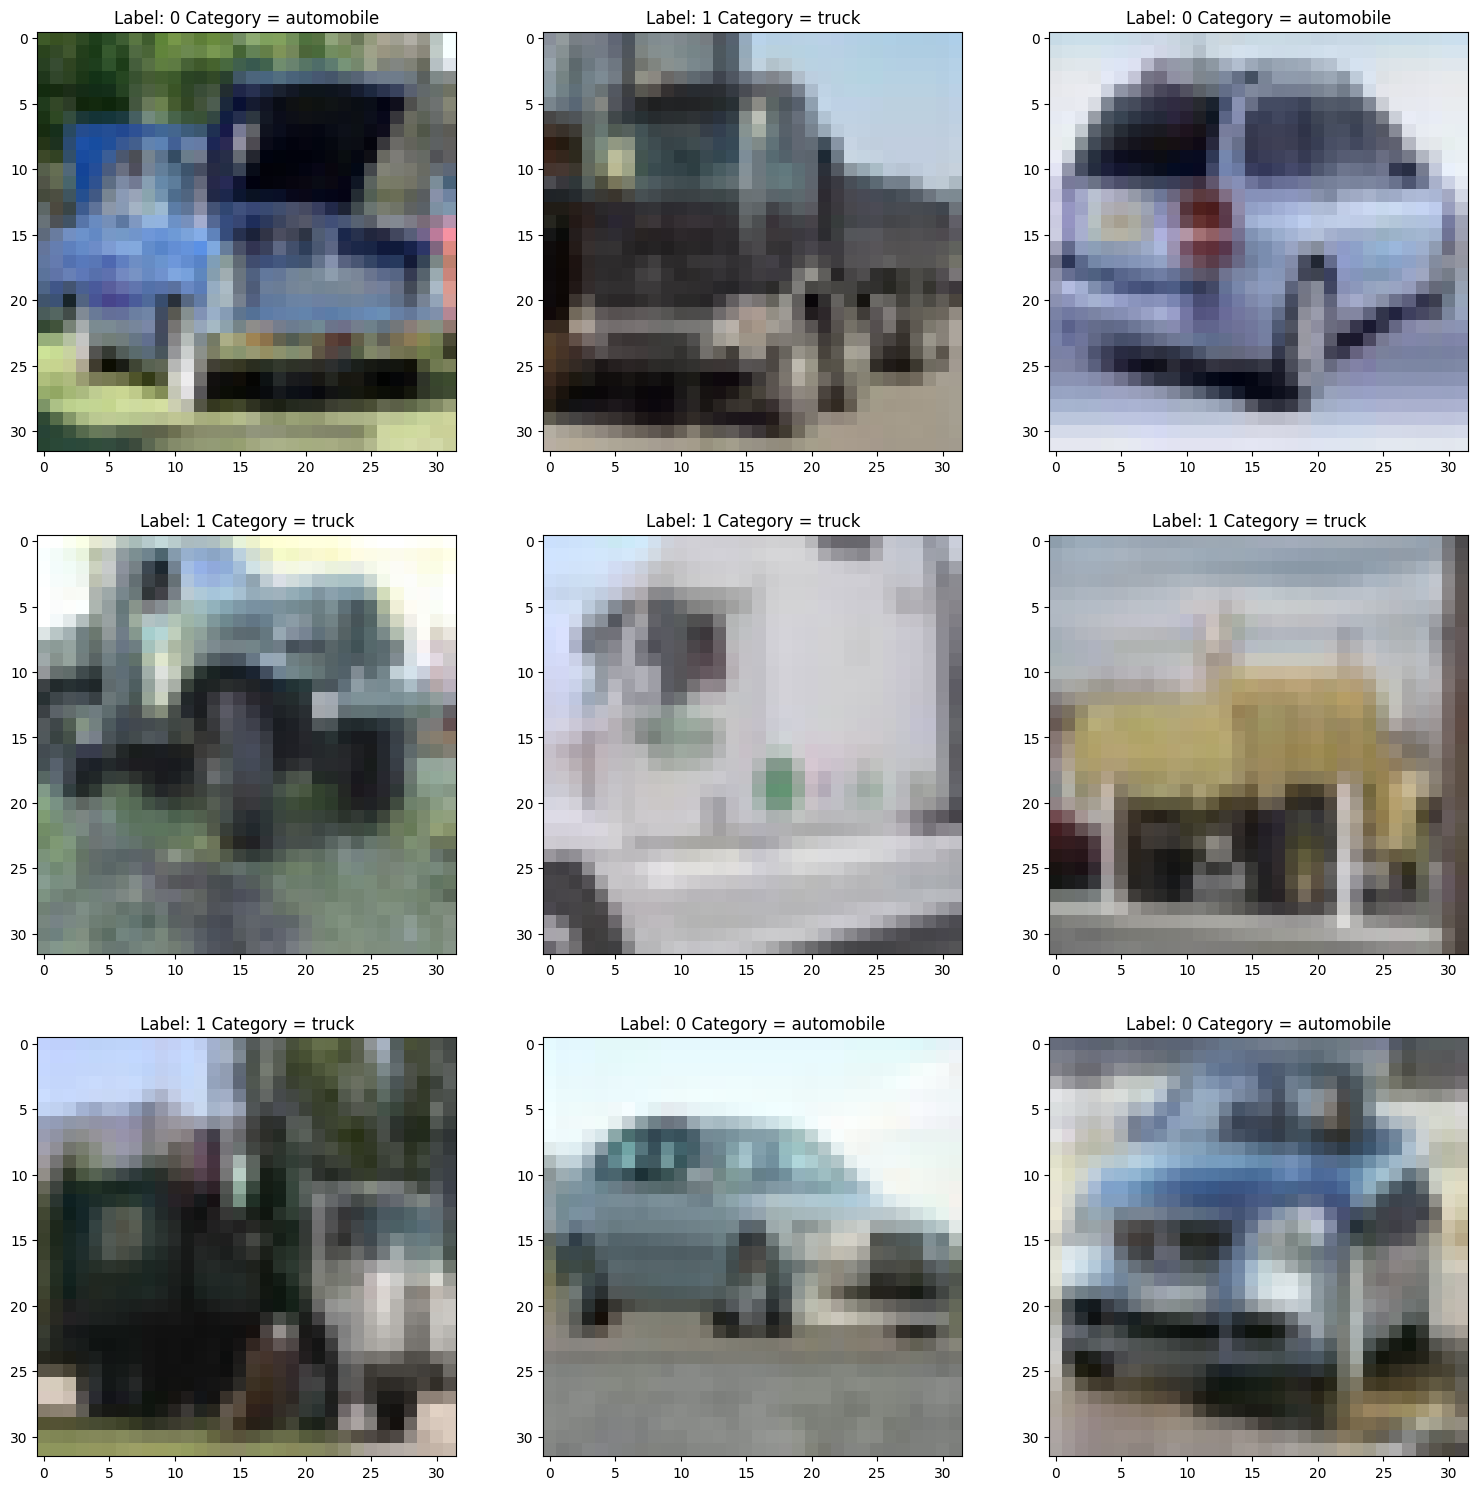

In [36]:
# 3. Select 9 random images from training set
img_idxs = np.random.choice(X_train.shape[0], 9, replace=False)
imgs = X_train[img_idxs]
img_labels = y_train[img_idxs]
label_names = ["automobile",
             "truck"]


# Plot images in 3x3 grid
fig = plt.figure(0)
fig.set_size_inches(18.5, 18.5)
for i in range(0,9):
    fig.add_subplot(3, 3, i+1)
    plt.imshow(imgs[i])
    plt.title("Label: {}".format(img_labels[i]) + " Category = " + str(label_names[img_labels[i]]))

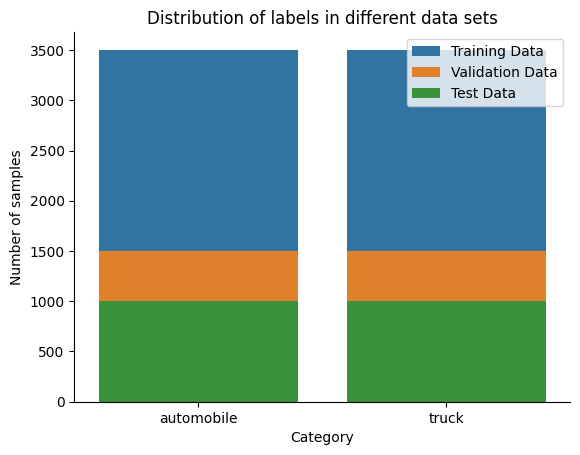

In [52]:
# 4. Plot distribution of labels
import seaborn as sns
cmap = sns.color_palette()

def plot_label_distribution(labels, title, c):
    unique_labels, label_counts = np.unique(labels, return_counts=True)
    label_names = ["automobile",
             "truck"]

    sns.barplot(x = unique_labels, y = label_counts, color = c, label = title)
    plt.xticks(unique_labels, label_names)
    plt.xlabel('Category')
    plt.ylabel('Number of samples')
    sns.despine()

plot_label_distribution(y_train, 'Training Data', c = cmap[0])
plot_label_distribution(y_val, 'Validation Data', c = cmap[1])
plot_label_distribution(y_test, 'Test Data', c = cmap[2])
plt.title('Distribution of labels in different data sets')
plt.legend()


## 2.2 Preprocessing

- Rescale the images data, so that the values lie between a range of 0 and 1.
- Hint: A simple way to do this is to divide by 255.0

In [66]:
# re-shape data
def rescale_imgs(imgs):
  rescaled_imgs = imgs/255.0
  return rescaled_imgs

X_train_rescaled = rescale_imgs(X_train)
X_test_rescaled = rescale_imgs(X_test)
X_val_rescaled = rescale_imgs(X_val)

## 2.3 Feedforward Neural Network

Reshape your data so that each image is flattened into a 1d array, and each of the train, test and validation sets are 2d arrays.

Essentially, your data should be an array of length N, where N is the number of observations (images) in the train / test / validation sets. Each element in the array is a flattened image, of length 3072 (32 X 32 X3)     


In [77]:
# Reshape the image data to flatten each image into a 1D array
X_train_flat = X_train_rescaled.reshape(X_train_rescaled.shape[0], -1)
X_test_flat = X_test_rescaled.reshape(X_test_rescaled.shape[0], -1)
X_val_flat = X_val_rescaled.reshape(X_val_rescaled.shape[0], -1)

# Verify shape
X_val_flat.shape

(3000, 3072)


### 2.3.1 Build a neural network with the following parameters

  - Architecture
     - Input dimensions: 3072
     - 1 hidden layer: 64 nodes, Relu activation
     - Output layer: 1 node, Sigmoid activation
 - Compile the network:
     - Optimizer: Adam
     - Epochs: 30
     - Batch size: 32
     - Metrics: Accuracy
     - Remember to include the validation data in the compilation step.
  - Outputs:
      - Plot the training and validation accuracy by epoch (See the example plot below). Do you see any evidence of overfitting in your plot?
      - Report the accuracy, Precision and Recall on the test set
      
**Example plot**

![ffn_performance](https://github.com/neurogomez/INFO201_AppliedMachineLearning/blob/main/PS/PS6/images/example_plot_ffn.png?raw=1)

In [82]:
import tensorflow as tf

# Define  model architecture
FFN = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_dim=X_train_flat.shape[1]),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
FFN.compile(optimizer='adam',
              loss='mse',
              metrics=['accuracy'])

# Define batch size and number of epochs
batch_size = 32
epochs = 30

# Train the model
results = FFN.fit(X_train_flat, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_flat, y_val))

Epoch 1/30
219/219 [==============================] - 3s 11ms/step - loss: 0.2485 - accuracy: 0.6196 - val_loss: 0.2089 - val_accuracy: 0.6717
Epoch 2/30
219/219 [==============================] - 2s 7ms/step - loss: 0.2077 - accuracy: 0.6716 - val_loss: 0.2332 - val_accuracy: 0.6360
Epoch 3/30
219/219 [==============================] - 2s 8ms/step - loss: 0.2013 - accuracy: 0.6910 - val_loss: 0.1983 - val_accuracy: 0.6977
Epoch 4/30
219/219 [==============================] - 2s 8ms/step - loss: 0.2019 - accuracy: 0.6899 - val_loss: 0.2066 - val_accuracy: 0.6703
Epoch 5/30
219/219 [==============================] - 1s 6ms/step - loss: 0.1898 - accuracy: 0.7096 - val_loss: 0.1983 - val_accuracy: 0.7020
Epoch 6/30
219/219 [==============================] - 1s 5ms/step - loss: 0.1860 - accuracy: 0.7166 - val_loss: 0.1998 - val_accuracy: 0.6843
Epoch 7/30
219/219 [==============================] - 1s 5ms/step - loss: 0.1898 - accuracy: 0.7136 - val_loss: 0.1987 - val_accuracy: 0.7037
Epoch

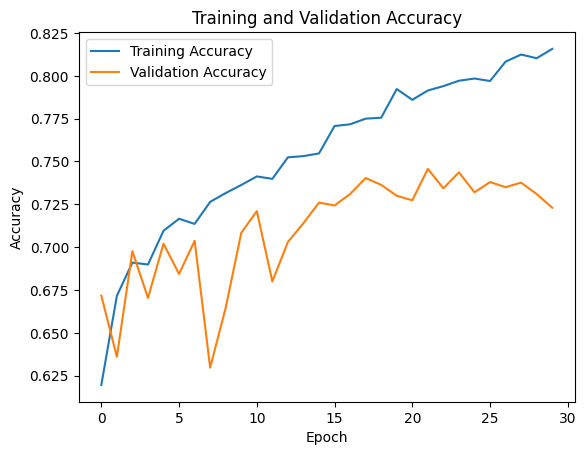

In [85]:
# Plot training and validation accuracy
plt.plot(results.history['accuracy'], label='Training Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

1. Do you see any evidence of overfiting in your plot?
- Yes, we see some evidence of overfitting since the gap between the training accuracy curve and validation accuracy curve begins to widen as a function of epoch number. The training accuracy improves throughout the whole trainng process but the validation accuracy plateaus after ~15 epochs, suggestive of overfitting.

In [91]:
# 2. Report accuracy, preiciosion and recall on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score

test_loss, test_accuracy = FFN.evaluate(X_test_flat, y_test)
print("Test Accuracy:", test_accuracy)

# Predict labels for the test set: convert probabilites to binary using 0.5 threshold
y_pred_prob = FFN.predict(X_test_flat)
y_pred = (y_pred_prob > 0.5).astype(int)


# Calculate precision and recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision on Test Set:", precision)
print("Recall on Test Set:", recall)

63/63 [==============================] - 0s 4ms/step - loss: 0.1973 - accuracy: 0.7225
Test Accuracy: 0.7225000262260437
63/63 [==============================] - 0s 2ms/step
Precision on Test Set: 0.8183118741058655
Recall on Test Set: 0.572


### 2.3.2. Tuning / Improving Performance

Now, go ahead and tune this network, or write up your own from scratch. The goal should be to exceed 75% overall classification accuracy on the test set. We don't expect you to implement cross-validation or any formal hyperparameter optimization techniques. Rather, the goal is to arrive at a model architecture that's acceptable to you via trial and error.  

Remember that you have a number of hyperparameters to work with, including
  - the number / dimension of hidden layers
  - choice of activation functions,
  - type regularization,
  - optimization techniques
  
Note that you shouldn't need to train your model for more than 30 epochs.
  
The notebooks from Labs 9 and 10 are also a good starting point.
  

**Outputs:**
- In 2-3 sentences, briefly explain the various choices/ decisions you made in building your model architecture.
- Report the classification accuracy on the test set, along with the precision and recall for each class.
- What do you notice about the precision and recall values, as well as the overall classification accuracy, in comparison to your outputs from 2.3.1?

In [169]:
# Define the new model architecture with L2 regularization

lmbd = 0.01

FFN_opt = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation=tf.keras.layers.LeakyReLU(alpha=0.01), input_dim=X_train_flat.shape[1], kernel_regularizer=tf.keras.regularizers.l2(lmbd)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = optimizer = tf.keras.optimizers.Adagrad(learning_rate=0.01)


FFN_opt.compile(optimizer=optimizer,
              loss='mse',
              metrics=['accuracy'])

# Define batch size and number of epochs
batch_size = 32
epochs = 30

# Train the model
results_opt = FFN_opt.fit(X_train_flat, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val_flat, y_val))


Epoch 1/30
219/219 [==============================] - 8s 28ms/step - loss: 1.3218 - accuracy: 0.6249 - val_loss: 1.1653 - val_accuracy: 0.6610
Epoch 2/30
219/219 [==============================] - 4s 20ms/step - loss: 1.0460 - accuracy: 0.6629 - val_loss: 0.9584 - val_accuracy: 0.6170
Epoch 3/30
219/219 [==============================] - 3s 12ms/step - loss: 0.8436 - accuracy: 0.6771 - val_loss: 0.7616 - val_accuracy: 0.6630
Epoch 4/30
219/219 [==============================] - 4s 17ms/step - loss: 0.6879 - accuracy: 0.6876 - val_loss: 0.6409 - val_accuracy: 0.6453
Epoch 5/30
219/219 [==============================] - 3s 13ms/step - loss: 0.5729 - accuracy: 0.6897 - val_loss: 0.5390 - val_accuracy: 0.6717
Epoch 6/30
219/219 [==============================] - 3s 11ms/step - loss: 0.4841 - accuracy: 0.7014 - val_loss: 0.4655 - val_accuracy: 0.6630
Epoch 7/30
219/219 [==============================] - 3s 13ms/step - loss: 0.4183 - accuracy: 0.6997 - val_loss: 0.3905 - val_accuracy: 0.6913

In [170]:
# Report accuracy, preicision and recall on the test set
from sklearn.metrics import classification_report

test_loss_opt, test_accuracy_opt = FFN_opt.evaluate(X_test_flat, y_test)
print("Test Accuracy:", test_accuracy_opt)

# Predict labels for the test set: convert probabilites to binary using 0.5 threshold
y_pred_prob_opt = FFN_opt.predict(X_test_flat)
y_pred_opt = (y_pred_prob_opt > 0.5).astype(int)


# Calculate precision and recall for each class
precision_auto = precision_score(y_test, y_pred_opt, pos_label=0)
recall_auto = recall_score(y_test, y_pred_opt, pos_label=0)

precision_truck = precision_score(y_test, y_pred_opt, pos_label=1)
recall_truck = recall_score(y_test, y_pred_opt, pos_label=1)

print("Precision for  'automobile':", precision_auto)
print("Recall for  'automobile':", recall_auto)

print("Precision for  'truck':", precision_truck)
print("Recall for  'truck':", recall_truck)

63/63 [==============================] - 0s 2ms/step - loss: 0.1931 - accuracy: 0.7535
Test Accuracy: 0.7534999847412109
63/63 [==============================] - 0s 3ms/step
Precision for  'automobile': 0.7752442996742671
Recall for  'automobile': 0.714
Precision for  'truck': 0.7349397590361446
Recall for  'truck': 0.793


1. In 2-3 sentences, briefly explain the various choices/ decisions you made in building your model architecture.
- Going off of Lab 9, I tried using L2 regularization with coefficient lambda = 0.1.
- I increased the number of hidden layers to 2, with the second layer containing 32 nodes and a ReLU  activation function.  
- Finally I looked into different optimizers and activation functions and settled on a learnable leaky ReLU function for the first hidden layer and  AdaGrad as the optimizer, which adapts the learning rate to the parameters. These achieved a test accuracy of over 75 %.

2. Report the classification accuracy on the test set, along with the precision and recall for each class.
- The values are reported above.


3. What do you notice about the precision and recall values, as well as the overall classification accuracy, in comparison to your outputs from 2.3.1?
- Overall, the test accuracy improved slightly from the first round using the simple parameters, increasing from 0.7225 to 0.7539. The precision for the automobile class was higher than that of the truck class while the recall truck was higher for the optimized FFN. Compared to 3.1, the precision on the test set was actually worse for both classes, while the recall was much higher. This is because there is a trade off between preicision and recall in binary classification tasks.

## 2.4. Convolutional Neural Network


### 2.4.1. Build a CNN with the following parameters

  - Architecture
     - Input dimensions: (32, 32,  3)
     - 1 Conv2D Layer:
         - Number of filters: 20.
         - Filter Dimension: 3 X 3.
         - Activation: Relu
     - Flatten
     - Output layer: 1 node, Sigmoid activation
 - Compile the network:
     - Optimizer: Adam
     - Epochs: 20
     - Metrics: Accuracy
     - Remember to include the validation data in the compilation step.
  - Outputs:
      - Plot the training and validation accuracy by epoch.
      - Report the accuracy, Precision and Recall on the test set

In [7]:

# Define the CNN model architecture
CNN = tf.keras.Sequential([
    tf.keras.layers.Conv2D(20, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
CNN.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define batch size and number of epochs
batch_size = 32
epochs = 20

# Train the model
results_CNN = CNN.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val))


Epoch 1/20
219/219 [==============================] - 8s 24ms/step - loss: 7.4146 - accuracy: 0.6210 - val_loss: 1.1229 - val_accuracy: 0.6427
Epoch 2/20
219/219 [==============================] - 3s 13ms/step - loss: 0.7547 - accuracy: 0.6791 - val_loss: 0.8224 - val_accuracy: 0.6593
Epoch 3/20
219/219 [==============================] - 4s 18ms/step - loss: 0.5414 - accuracy: 0.7470 - val_loss: 0.7650 - val_accuracy: 0.6817
Epoch 4/20
219/219 [==============================] - 3s 13ms/step - loss: 0.4129 - accuracy: 0.8151 - val_loss: 0.9386 - val_accuracy: 0.6817
Epoch 5/20
219/219 [==============================] - 3s 12ms/step - loss: 0.3358 - accuracy: 0.8554 - val_loss: 0.8480 - val_accuracy: 0.7133
Epoch 6/20
219/219 [==============================] - 3s 12ms/step - loss: 0.2798 - accuracy: 0.8796 - val_loss: 0.8501 - val_accuracy: 0.7140
Epoch 7/20
219/219 [==============================] - 4s 19ms/step - loss: 0.2282 - accuracy: 0.9070 - val_loss: 0.8739 - val_accuracy: 0.7423

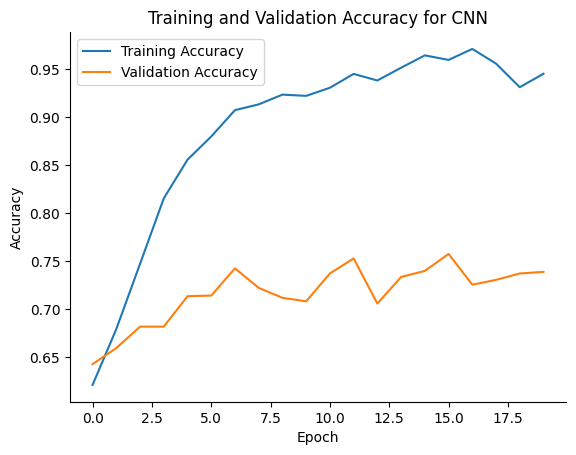

In [11]:
# Plot training and validation accuracy
plt.plot(results_CNN.history['accuracy'], label='Training Accuracy')
plt.plot(results_CNN.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
sns.despine()
plt.title('Training and Validation Accuracy for CNN')
plt.show()

In [12]:
# Report accuracy, precision, and recall on the test set
test_loss, test_accuracy_CNN = CNN.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy_CNN)

# Predict labels for the test set: convert probabilities to binary using 0.5 threshold
y_pred_prob_CNN = CNN.predict(X_test)
y_pred_CNN = (y_pred_prob_CNN > 0.5).astype(int)

# Calculate precision and recall
precision_CNN = precision_score(y_test, y_pred_CNN)
recall_CNN = recall_score(y_test, y_pred_CNN)

print("Precision on Test Set:", precision_CNN)
print("Recall on Test Set:", recall_CNN)

63/63 [==============================] - 0s 5ms/step - loss: 1.5675 - accuracy: 0.7465
Test Accuracy: 0.7465000152587891
63/63 [==============================] - 0s 5ms/step
Precision on Test Set: 0.7340930674264008
Recall on Test Set: 0.773


### 2.4.2. Tuning / Improving Performance

Now, go ahead and tune this network, or write up your own from scratch. The goal should be to exceed 85% overall classification accuracy on the test set. We don't expect you to implement cross-validation or any formal hyperparameter optimization techniques. Rather, the goal is to arrive at a model architecture that's acceptable to you via trial and error.

Note that you shouldn't need to train your model for more than 30 epochs.

Remember that you have a number of hyperparameters to work with, including
  - the number / dimension of hidden layers
  - choice of activation functions,
  - type regularization,
  - optimization techniques
  - and other relevant aspects(adding data augmentation etc.)
  
The notebooks from Labs 9 and 10 are a good starting point in terms of putting together a more complex architecture.

<span style="color:red">Warning!</span> If you intend to attempt **Extra Credit 1 and 2** (below), ensure that you carefully name / store the trained model you build in this step. It's fine to keep trained model in memory, or to save the weights to disk.

  

**Outputs:**
 - Report the classification accuracy on the test set, along with the precision and recall for each class.
 - Briefly explain your model architecture / choices you made in tuning your CNN (No more than 3 - 4 sentences)
 - What do you notice about the precision and recall values, as well as the overall classification accuracy, in comparison to the feed forward neural networks from part 2.3, and your baseline in 2.4.1?

In [24]:
## OPTIMIZATION
# Define the CNN model architecture
lmbd1 = 0.01

CNN_opt = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

CNN_opt.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define batch size and number of epochs
batch_size = 32
epochs = 20

# Train the model
results_CNN_opt = CNN_opt.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_data=(X_val, y_val))


Epoch 1/20
219/219 [==============================] - 29s 116ms/step - loss: 1.1527 - accuracy: 0.5069 - val_loss: 0.6881 - val_accuracy: 0.5087
Epoch 2/20
219/219 [==============================] - 17s 78ms/step - loss: 0.6642 - accuracy: 0.5661 - val_loss: 0.5948 - val_accuracy: 0.7110
Epoch 3/20
219/219 [==============================] - 15s 70ms/step - loss: 0.6147 - accuracy: 0.6466 - val_loss: 0.6129 - val_accuracy: 0.6613
Epoch 4/20
219/219 [==============================] - 14s 65ms/step - loss: 0.5554 - accuracy: 0.7080 - val_loss: 0.4898 - val_accuracy: 0.7717
Epoch 5/20
219/219 [==============================] - 14s 64ms/step - loss: 0.4885 - accuracy: 0.7799 - val_loss: 0.4858 - val_accuracy: 0.7850
Epoch 6/20
219/219 [==============================] - 17s 78ms/step - loss: 0.4487 - accuracy: 0.8077 - val_loss: 0.5154 - val_accuracy: 0.7477
Epoch 7/20
219/219 [==============================] - 19s 87ms/step - loss: 0.4007 - accuracy: 0.8297 - val_loss: 0.3459 - val_accuracy

In [25]:
# Report accuracy, precision, and recall on the test set
test_loss, test_accuracy_CNN_opt = CNN_opt.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy_CNN_opt)

# Predict labels for the test set: convert probabilities to binary using 0.5 threshold
y_pred_prob_CNN_opt = CNN_opt.predict(X_test)
y_pred_CNN_opt = (y_pred_prob_CNN_opt > 0.5).astype(int)


# Calculate precision and recall for each class
precision_auto = precision_score(y_test, y_pred_CNN_opt, pos_label=0)
recall_auto = recall_score(y_test, y_pred_CNN_opt, pos_label=0)

precision_truck = precision_score(y_test, y_pred_CNN_opt, pos_label=1)
recall_truck = recall_score(y_test, y_pred_CNN_opt, pos_label=1)

print("Precision for  'automobile':", precision_auto)
print("Recall for  'automobile':", recall_auto)

print("Precision for  'truck':", precision_truck)
print("Recall for  'truck':", recall_truck)

63/63 [==============================] - 1s 12ms/step - loss: 0.4319 - accuracy: 0.8935
Test Accuracy: 0.8934999704360962
63/63 [==============================] - 1s 11ms/step
Precision for  'automobile': 0.899492385786802
Recall for  'automobile': 0.886
Precision for  'truck': 0.8876847290640394
Recall for  'truck': 0.901


1. Report the classification accuracy on the test set, along with the precision and recall for each class.
- These values are reported above.
2. Briefly explain your model architecture / choices you made in tuning your CNN (No more than 3 - 4 sentences)
- After using a similar apporach to 2.3, I found very little improvement in the accuruacy so instead I just added many more hidden layers including MaxPooling2D layers interpspaceed between Conv2D layers of increasing number of nodes, which greatly improved things. Next I used a dense layer with 64 nodes and a dropout regularization layer prior to the output layer to obtain a final test accuracy of 0.893.
3.  What do you notice about the precision and recall values, as well as the overall classification accuracy, in comparison to the feed forward neural networks from part 2.3, and your baseline in 2.4.1?
- Compared to the optimized FNN in 2.3, the overall classification accuracy is much larger (0.89 vs 0.75). The preicision and recall for each category (both truck and automobile), is much larger also for the CNN model increasing from preciision= ~0.75 and recall= ~0.72 for the FFN to preicision = ~0.89 and recall ~0.89 for the CNN. Comparing the optimizde model to the baseline in 2.4.1, we find the test accuracy and preicision and recall are significantly higher also, a hugh improvement from the FFN model.

### 2.5: Convolutional Filters

Now, let's attempt to better understand what our CNN is doing under the hood. We'll start by visually examining our convolutional filters.

- We'll focus on the first convolutional layer in your CNN.
    - Use the [get_weights()](https://keras.io/api/layers/base_layer/#getweights-method) method to obtain the filters.
    - Plot the first 5 filters, for each channel (your plot will be a grid of 5 X 3).
    - Your plot will resemble the one below (the exact nature of the visual patterns will depend on your model architecture etc.)
    - What do you observe about the filters you visualize?
    
**Example output**
 ![Example](https://github.com/neurogomez/INFO201_AppliedMachineLearning/blob/main/PS/PS6/images/filters.png?raw=1)

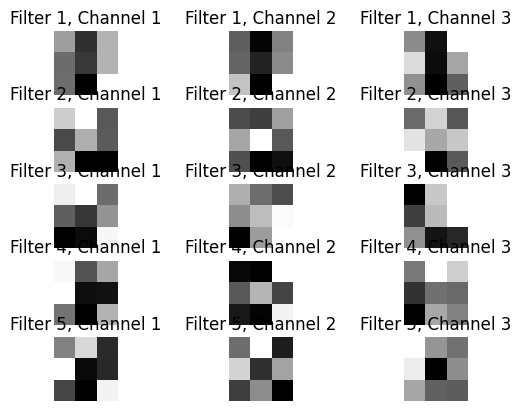

In [26]:
# Get the weights of the first convolutional layer
conv_weights = CNN_opt.layers[0].get_weights()[0]

# Plot the first 5 filters for each channel
num_filters = 5
num_channels = conv_weights.shape[2]

for i in range(num_filters):
    for j in range(num_channels):
        plt.subplot(num_filters, num_channels, i * num_channels + j + 1)
        plt.imshow(conv_weights[:, :, j, i], cmap='gray')
        plt.axis('off')
        plt.title(f'Filter {i+1}, Channel {j+1}')

1. What do you observe about the filters you visualize?
 - The first filter typically capture s low-level features such as edges and corners. Here we can see that the different filters in each channel lookd like edge detectors with different orienatation and spatial location in the 3x3 grid.

### Extra Credit 1: Feature Maps

A feature map, or an activation map allows us to examine the result of applying the filters to a given input. The broad intuition is that feature maps closer to the input image detect fine-grained detail, whereas feature maps closer to the output of the model capture more generic aspects.

Your task is to create and visualize a feature map (i.e the outputs) from the first convolutional layer in your trained CNN.

In order to do this, proceed as follows:
- Identify a nice image from your training data -- ideally, something that has some distinguishing properties to the naked eye.
- Pass this image through your trained CNN from **2.4.2**, and store the output from the first convolutional layer -- this is your feature map! Note that there are multiple ways to do this; the simplest is to create a copy of your trained CNN, and remove the later layers. The Models function can help you do this.
- Note that the size of the feature map depends on how many filters you have in the layer.
- Outputs:
    - plot 1) The raw image from the training data, and 2) the feature map. An example is shown below:
    - what do you observe about the feature maps?
    
**Raw Image**
![Plane](https://github.com/neurogomez/INFO201_AppliedMachineLearning/blob/main/PS/PS6/images/plane1.png?raw=1)

**Feature Map**
![Plane-features](https://github.com/neurogomez/INFO201_AppliedMachineLearning/blob/main/PS/PS6/images/plane_feature_map.png?raw=1)

1/1 [==============================] - 0s 45ms/step


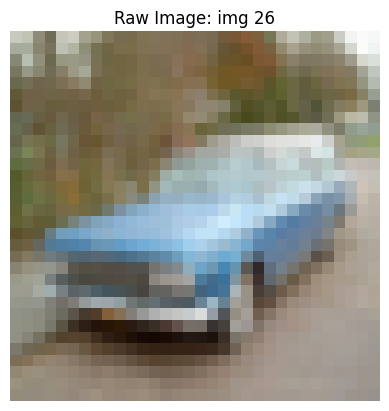

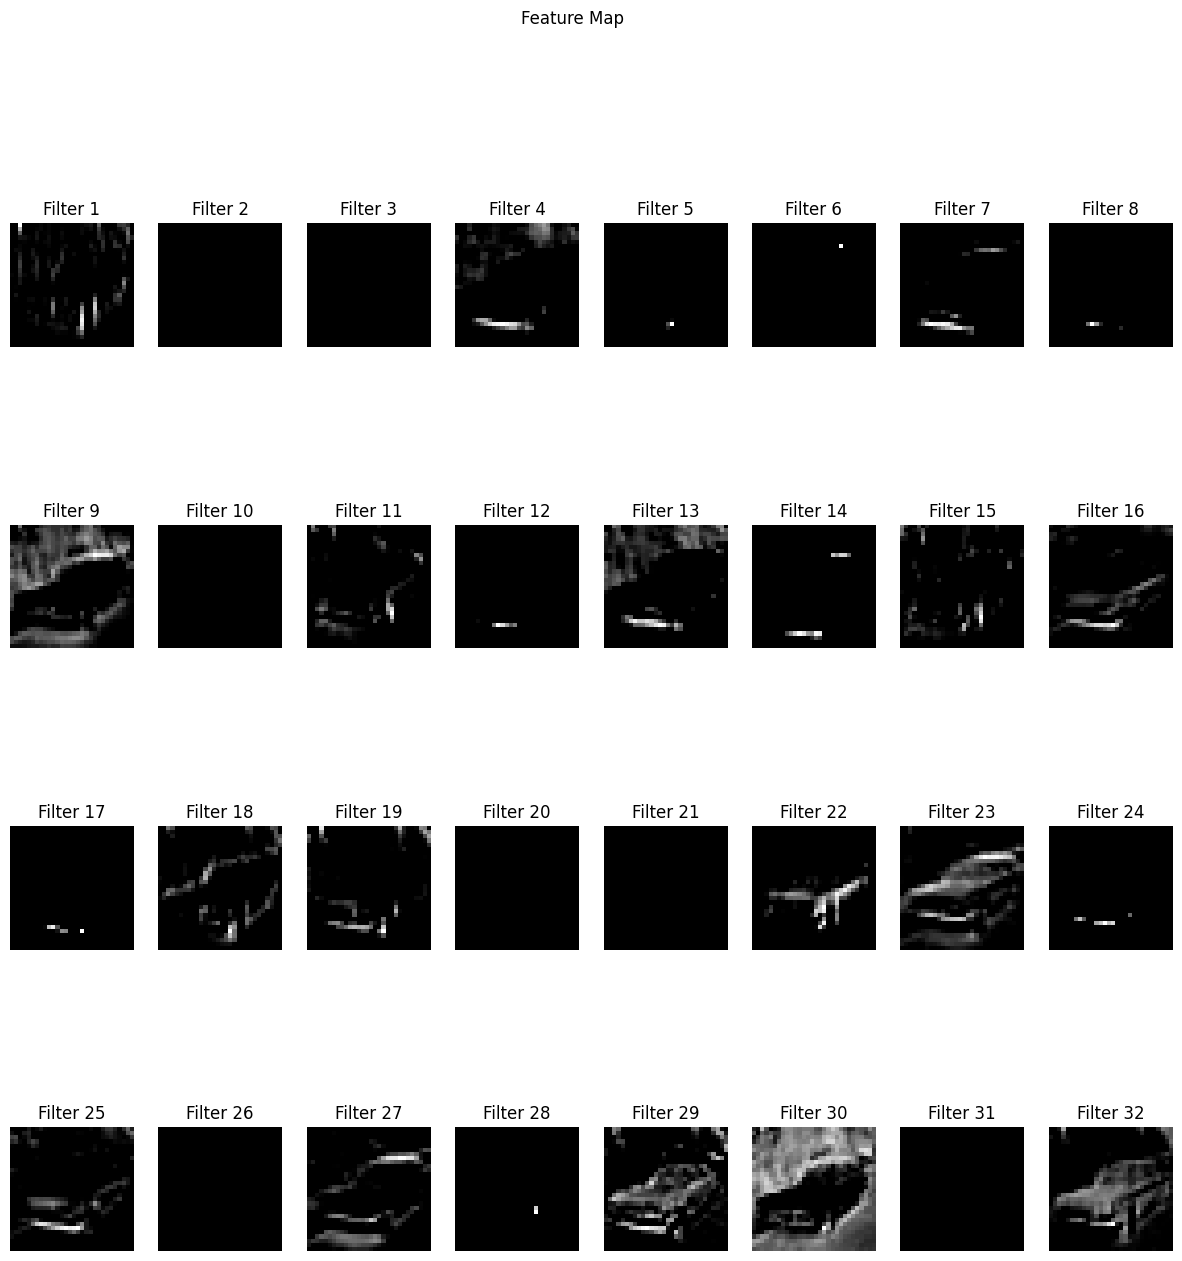

In [37]:
# Select an image from the training data
sample_image = X_train[26]

# Create a copy of the trained CNN with only the first convolutional layer
conv_layer_model = tf.keras.models.Model(inputs=CNN_opt.input, outputs=CNN_opt.layers[0].output, name = "CNN_opt")

# Get the feature map from the first convolutional layer
input_image = np.expand_dims(sample_image, axis=0)
feature_maps = conv_layer_model.predict(input_image)

# Plot the raw image
plt.imshow(sample_image)
plt.title('Raw Image: img 26')
plt.axis('off')
plt.show()

# Plot the feature maps for all filters
num_filters = feature_maps.shape[-1]
plt.figure(figsize=(15, 15))
for i in range(num_filters):
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='gray')
    plt.title(f'Filter {i+1}')
    plt.axis('off')
plt.suptitle('Feature Map')
plt.show()



1. What do you observe about the feature maps?
- Each filter applied to the input image in this feature map is optimized for detecting specific patterns: from borders, edges or textures, to more complex structures such as high freauency features in the image. Indeed we find that some feature maps detect fine-grained detail where the car outline is clearly discernable. Some features are captrure more generic aspects high contrast regions and low spatial frequency information like background.

### Extra Credit 2: Transfer Learning / Fine tuning


Suppose you have a slightly different classification task at hand: to correctly separate trucks from airplanes.

We'll examine how we can use an already trained model to do this, instead of coding up a new neural network from scratch.

You are required to implement two approaches:

- First, we'll use the CNN from D2 above -- and simply update the weights.
- Second, we'll load a pre-trained model from keras/ tensorflow (e.g. ResNet50, or VGG19). While these models haven't seen the exact images in this dataset, they have been trained on a large general corpus. Since these models have millions of weights, so we'll implement the following approach:
    - Load a pre-trained model
    - Freeze the weights by setting trainable = False.
    - Build a new model by adding additional layers to the base model.
    - Train the new model and evaluate performance.
    
- Compare the performance of both approaches, and briefly summarize your observations

We have provided some helper code and hints in the cells below.
    
<span style="color:red">Warning!</span> Note that the second approach could be slow / time-consuming. If you are attempting it, please ensure that you budget ~20 mins to 1hour (worst case) for the code to complete running for this part.

This is a handy reference: https://keras.io/guides/transfer_learning/#transfer-learning-amp-finetuning

In [ ]:
def cifar_2moreclasses(pos_class, neg_class):
    """
    Helper code to clean the CIFAR 10 dataset, and remove the unnecessary classes.
    """
    ## Load data
    label_names = ["airplane",
             "automobile",
             "bird",
             "cat",
             "deer",
             "dog",
             "frog",
             "horse",
             "ship",
             "truck"]


    label_map = {i:99 for i in range(len(label_names))}
    label_map[pos_class] = 1
    label_map[neg_class] = 0

    (X_train_val, y_train_val), (X_test, y_test) = cifar10.load_data()

    (X_train_val, y_train_val), (X_test, y_test) = cifar10.load_data()
    y_train_val1 = np.array([[label_map[y[0]]] for y in y_train_val])
    y_test1 = np.array([[label_map[y[0]]] for y in y_test])

    X_train_val_clean = X_train_val[np.where(y_train_val1 != 99)[0]]
    y_train_val_clean =  y_train_val1[np.where(y_train_val1 != 99)]

    X_test_clean = X_test[np.where(y_test1 != 99 )[0]]
    y_test_clean = y_test1[np.where(y_test1 != 99)]

    return X_train_val_clean, y_train_val_clean, X_test_clean, y_test_clean

In [ ]:
## Load data
X_train_val1, y_train_val1, X_test1, y_test1 = cifar_2moreclasses(9, 0)

## Split into train, validation and test.
N_train, N_validation, N_test = 7000, 3000, 2000

X_train1 = X_train_val1[:N_train,:,:]
y_train1 = y_train_val1[:N_train]

X_val1 = X_train_val1[N_train: N_train + N_validation,:,:]
y_val1 = y_train_val1[N_train: N_train + N_validation]

X_test1 = X_test1[:N_test]
y_test1 = y_test1[:N_test]

print(X_train1.shape, X_val1.shape, X_test1.shape)

(7000, 32, 32, 3) (3000, 32, 32, 3) (2000, 32, 32, 3)


In [ ]:
#### APPROACH 1

In [ ]:
from keras.models import clone_model

# Helper Code: Cloning the model (Edit the line below with the name of your model from D2)
model_cnn3 = clone_model( model_from_D2 )

# To do: Compile the model

# To do: Copy weights from model_from_D2.
#Reference: https://keras.io/2.15/api/models/model_saving_apis/weights_saving_and_loading/


# To do: Preprocess the data

# To do: Train this model (10 epochs)


#To do: Evaluate performance


In [ ]:
### APPROACH 2

In [ ]:


## Helper code: load pre-trained model. Feel free to load something else.
## Available options can be found here: https://keras.io/api/applications/#keras-applications

from keras.applications import ResNet50
base_model_1 = ResNet50(include_top = False, weights='imagenet',input_shape=(32,32,3))

## To Do: Freeze the weights


## Now initialize a new model -- add the pre-trained weights, along with some additional layers.
# Hint / helper code -- here's one way to do this, but feel free to use your own.
# model_1= Sequential()
# model_1.add(base_model_1)
# model_1.add(Flatten())



# To Do: Add new dense layers along with Dropout etc. Add at least 2 dense layers -- you are free to pick the number of nodes.
# Remember to finish with the classification head (i.e Dense layer with 1 node and sigmoid activation. )


## To Do: Compile the Model


In [ ]:
## To do: print the model summary. Ensure that weights for the pre-trained model are frozen.


In [ ]:
## To do: Fit the model for 10 epochs.


In [ ]:
#To do: Evaluate model performance

